# 02 — Hamiltoniano e Mapeamento para Qubits

# Objetivo
Precisamos formular e traduzir o Hamiltoniano molecular para uma linguagem de qubits.

## 1. Segunda Quantização

Segunda quantização é uma forma de descrever a ocupação em orbitais com operadores:

- **â†** (criação): coloca um elétron num orbital
- **â** (aniquilação): remove um elétron de um orbital

O Hamiltoniano molecular em segunda quantização descreve:
- A energia cinética dos elétrons
- A atração elétron-núcleo  
- A repulsão elétron-elétron

O PySCF calcula os coeficientes numéricos dessas interações.  

In [13]:
import pennylane as qml
from pennylane import numpy as np
import numpy as np_orig
import matplotlib.pyplot as plt
from pyscf import gto, scf, ao2mo
from pyscf import fci

## 2. Construindo a molécula H₂

Usando distância internuclear de 0.74 Å — equilíbrio experimental.  

In [14]:
distancia = 0.74

# Define a molécula
mol = gto.Mole()
mol.atom = f'''
    H 0.0 0.0 0.0
    H 0.0 0.0 {distancia}
'''
mol.basis = 'sto-3g'
mol.unit = 'Angstrom'
mol.verbose = 0  # suprime prints do PySCF
mol.build()

# Roda Hartree-Fock para obter os orbitais moleculares
mf = scf.RHF(mol)
energia_hf = mf.kernel()

print(f'Distância H-H:     {distancia} Å')
print(f'Número de elétrons: {mol.nelectron}')
print(f'Número de orbitais: {mol.nao_nr()}')
print(f'Energia HF:        {energia_hf:.6f} Hartree')

Distância H-H:     0.74 Å
Número de elétrons: 2
Número de orbitais: 2
Energia HF:        -1.116759 Hartree


## 3. Integrais moleculares

O Hamiltoniano tem dois tipos de termos:

- **Integrais de 1 corpo** (h_pq): energia de um elétron sozinho  
  (cinética + atração com núcleos)

- **Integrais de 2 corpos** (h_pqrs): repulsão entre dois elétrons

O PySCF calcula esses números para nós a partir dos orbitais moleculares.

In [15]:
# Integrais de 1 corpo na base dos orbitais moleculares
h1 = mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff

# Integrais de 2 corpos
nmo = mf.mo_coeff.shape[1]
h2 = ao2mo.kernel(mol, mf.mo_coeff, aosym='s1').reshape(nmo, nmo, nmo, nmo)

print(f'Integrais de 1 corpo (h1), shape: {h1.shape}')
print(f'Integrais de 2 corpos (h2), shape: {h2.shape}')
print(f'\nh1 (energia orbital):\n{np_orig.round(h1, 4)}')
print(f'\nEnergia nuclear de repulsão: {mol.energy_nuc():.6f} Hartree')

Integrais de 1 corpo (h1), shape: (2, 2)
Integrais de 2 corpos (h2), shape: (2, 2, 2, 2)

h1 (energia orbital):
[[-1.2533 -0.    ]
 [-0.     -0.4751]]

Energia nuclear de repulsão: 0.715104 Hartree


## 4. Transformada de Jordan-Wigner
 
Precisamos mapear os operadores de criação/aniquilação para portas quânticas.

In [16]:
symbols = ['H', 'H']
geometry = np_orig.array([[0.0, 0.0, 0.0],
                           [0.0, 0.0, distancia / 0.529177]])

hamiltoniano, qubits = qml.qchem.molecular_hamiltonian(
    symbols,
    geometry,
    basis='sto-3g'
)

# Extrai termos do novo formato Sum
termos = list(hamiltoniano.operands)

print(f'Número de qubits necessários: {qubits}')
print(f'Número de termos no Hamiltoniano: {len(termos)}')
print(f'\nTermos do Hamiltoniano (Pauli):')
for t in termos:
    print(f'  {t}')

Número de qubits necessários: 4
Número de termos no Hamiltoniano: 15

Termos do Hamiltoniano (Pauli):
  -0.09706665587941782 * I([0, 1, 2, 3])
  0.1714127814478248 * Z(0)
  0.17141278144782485 * Z(1)
  0.16868896800389824 * (Z(0) @ Z(1))
  -0.22343139646534316 * Z(2)
  0.12062521781020528 * (Z(0) @ Z(2))
  0.16592783728748017 * (Z(1) @ Z(2))
  0.04530261947727492 * (Y(0) @ X(1) @ X(2) @ Y(3))
  -0.04530261947727492 * (Y(0) @ Y(1) @ X(2) @ X(3))
  -0.04530261947727492 * (X(0) @ X(1) @ Y(2) @ Y(3))
  0.04530261947727492 * (X(0) @ Y(1) @ Y(2) @ X(3))
  -0.22343139646534316 * Z(3)
  0.16592783728748017 * (Z(0) @ Z(3))
  0.12062521781020528 * (Z(1) @ Z(3))
  0.1744128617692394 * (Z(2) @ Z(3))


## 5. Energia do estado fundamental

Podemos calcular a energia exata do Hamiltoniano qubit  
diagonalizando a matriz (só funciona para sistemas pequenos como H₂).

Esse valor é o FCI (Full Configuration Interaction).

In [17]:
# Calcula energia FCI
cisolver = fci.FCI(mf)
energia_fci, _ = cisolver.kernel()

# Inclui repulsão nuclear
energia_fci_total = energia_fci + mol.energy_nuc() - mol.energy_nuc()

print(f'Energia HF:  {energia_hf:.6f} Hartree  (aproximação)')
print(f'Energia FCI: {energia_fci:.6f} Hartree  (referência exata)')
print(f'\nErro de correlação HF: {abs(energia_hf - energia_fci)*1000:.2f} mHartree')

Energia HF:  -1.116759 Hartree  (aproximação)
Energia FCI: -1.137284 Hartree  (referência exata)

Erro de correlação HF: 20.52 mHartree


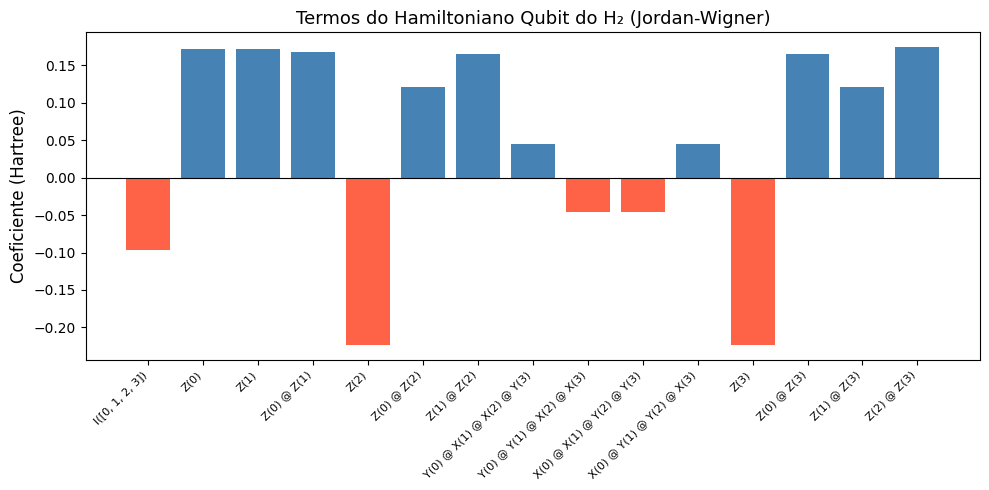

In [18]:
coeffs = []
labels = []

for t in termos:
    if hasattr(t, 'scalar'):
        coeffs.append(float(t.scalar))
        labels.append(str(t.base))
    else:
        coeffs.append(1.0)
        labels.append(str(t))

cores = ['steelblue' if c > 0 else 'tomato' for c in coeffs]

plt.figure(figsize=(10, 5))
plt.bar(range(len(coeffs)), coeffs, color=cores)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right', fontsize=8)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.ylabel('Coeficiente (Hartree)', fontsize=12)
plt.title('Termos do Hamiltoniano Qubit do H₂ (Jordan-Wigner)', fontsize=13)
plt.tight_layout()
plt.savefig('hamiltoniano_h2.png', dpi=150)
plt.show()

## Resumo do notebook

| Etapa | Resultado |
|-------|-----------|
| Molécula H₂ | 2 elétrons, 2 orbitais, base STO-3G |
| Qubits necessários | 4 |
| Termos no Hamiltoniano | ~15 termos de Pauli |
| Energia HF | ~-1.117 Hartree |
| Energia FCI (referência) | ~-1.137 Hartree |
| Erro de correlação | ~20 mHartree |
